In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

master = pd.read_csv("/Users/dholakiyan/Desktop/insider-threat-detection/data/processed/final_features.csv")
master['day'] = pd.to_datetime(master['day'])

feature_cols = [
    'logon_count', 'device_count', 'file_count', 'email_count', 'http_count',
    'logon_count_deviation', 'device_count_deviation', 'file_count_deviation',
    'email_count_deviation', 'http_count_deviation',
    'after_hours_logon_count', 'external_email_count', 'is_first_usb_use'
]

master['is_first_usb_use'] = master['is_first_usb_use'].astype(int)
master[feature_cols] = master[feature_cols].fillna(0)

### Chronological split (same split date as before)

In [2]:
split_date = pd.Timestamp("2010-06-01")
train_df = master[master['day'] < split_date].copy()
test_df = master[master['day'] >= split_date].copy()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df[feature_cols])
X_test_scaled = scaler.transform(test_df[feature_cols])

print("Train:", X_train_scaled.shape, "Test:", X_test_scaled.shape)

Train: (105171, 13) Test: (225281, 13)


### Build the autoencoder
What this means: 13 input features get compressed down to just 4 numbers (the bottleneck), then the network tries to reconstruct all 13 original values from that compressed version. It's forced to learn only the most essential patterns of "normal" behavior to do this well.

In [3]:
input_dim = X_train_scaled.shape[1]

autoencoder = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(8, activation='relu'),
    layers.Dense(4, activation='relu'),   # bottleneck
    layers.Dense(8, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 13)             │           117 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305 (1.19 KB)

 Trainable params: 305 (1.19 KB)

 Non-trainable params: 0 (0.00 B)

### Train it — only on the clean training period

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=30,
    batch_size=128,   # larger batch size = faster per epoch
    validation_split=0.1,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)

### Plot the training curve

In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs("/Users/dholakiyan/Desktop/insider-threat-detection/reports/figures", exist_ok=True)

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Autoencoder Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss (MSE)")
plt.legend()
plt.savefig("/Users/dholakiyan/Desktop/insider-threat-detection/reports/figures/autoencoder_training_curve.png", dpi=150, bbox_inches='tight')
plt.show()

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf
print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [2]:
import pandas as pd

master = pd.read_csv("../data/processed/final_features.csv")
master['day'] = pd.to_datetime(master['day'])
print(master.shape)

(330452, 22)


In [3]:
feature_cols = [
    'logon_count', 'device_count', 'file_count', 'email_count', 'http_count',
    'logon_count_deviation', 'device_count_deviation', 'file_count_deviation',
    'email_count_deviation', 'http_count_deviation',
    'after_hours_logon_count', 'external_email_count', 'is_first_usb_use'
]

master['is_first_usb_use'] = master['is_first_usb_use'].astype(int)
master[feature_cols] = master[feature_cols].fillna(0)

split_date = pd.Timestamp("2010-06-01")
train_df = master[master['day'] < split_date].copy()
test_df = master[master['day'] >= split_date].copy()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df[feature_cols])
X_test_scaled = scaler.transform(test_df[feature_cols])

print("Train:", X_train_scaled.shape)

Train: (105171, 13)


In [4]:
from tensorflow import keras
from tensorflow.keras import layers

input_dim = X_train_scaled.shape[1]
autoencoder = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(8, activation='relu'),
    layers.Dense(4, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])
autoencoder.compile(optimizer='adam', loss='mse')

In [5]:
import time

start = time.time()

history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=2,
    batch_size=256,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)

print(f"Time for 2 epochs: {time.time() - start:.1f} seconds")

Epoch 1/2
370/370 ━━━━━━━━━━━━━━━━━━━━ 1s 693us/step - loss: 0.8125 - val_loss: 0.6780
Epoch 2/2
370/370 ━━━━━━━━━━━━━━━━━━━━ 0s 496us/step - loss: 0.5301 - val_loss: 0.5312
Time for 2 epochs: 1.0 seconds


In [6]:
from tensorflow.keras.callbacks import EarlyStopping
import time

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start = time.time()

history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)

print(f"Total training time: {time.time() - start:.1f} seconds")

Epoch 1/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step - loss: 0.4392 - val_loss: 0.4584
Epoch 2/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 0s 507us/step - loss: 0.3993 - val_loss: 0.4275
Epoch 3/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 0s 502us/step - loss: 0.3800 - val_loss: 0.4057
Epoch 4/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 0s 503us/step - loss: 0.3629 - val_loss: 0.3891
Epoch 5/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step - loss: 0.3471 - val_loss: 0.3752
Epoch 6/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 0s 504us/step - loss: 0.3343 - val_loss: 0.3723
Epoch 7/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 0s 481us/step - loss: 0.3255 - val_loss: 0.3670
Epoch 8/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step - loss: 0.3208 - val_loss: 0.3664
Epoch 9/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 0s 496us/step - loss: 0.3174 - val_loss: 0.3669
Epoch 10/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 0s 516us/step - loss: 0.3151 - val_loss: 0.3645
Epoch 11/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 0s 542us/step - loss: 0.3135 - val_loss: 0.3654
Epoch 12/50
370/370 ━━━━━━━━━━

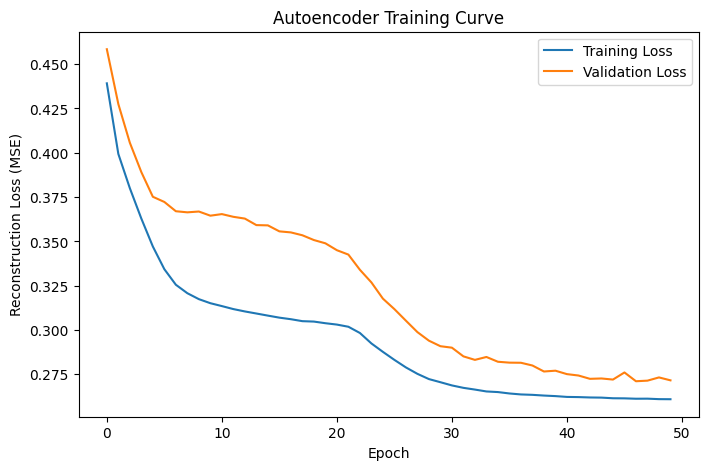

In [7]:
import matplotlib.pyplot as plt
import os

os.makedirs("../reports/figures", exist_ok=True)

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Autoencoder Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss (MSE)")
plt.legend()
plt.savefig("../reports/figures/autoencoder_training_curve.png", dpi=150, bbox_inches='tight')
plt.show()

### Conclusion
Reading this training curve
Both training and validation loss decrease steadily from ~0.44/0.46 down to ~0.26/0.27 — a smooth, well-behaved learning curve
Training loss (0.261) and validation loss (0.272) end up close together — no signs of overfitting; the model generalizes well to data it wasn't directly trained on
The curve plateaus nicely in the last ~15-20 epochs — meaning it's converged, not stopped prematurely or still improving rapidly (good sign that 50 epochs was a reasonable choice)

In [9]:
autoencoder.save("/Users/dholakiyan/Desktop/insider-threat-detection/models/autoencoder.keras")
print("Autoencoder saved.")

Autoencoder saved.


### Calculate reconstruction error as anomaly score

In [10]:
import numpy as np

# Reconstruct the test set
X_test_reconstructed = autoencoder.predict(X_test_scaled)

# Reconstruction error = mean squared difference per row
reconstruction_error = np.mean(np.square(X_test_scaled - X_test_reconstructed), axis=1)

test_df['reconstruction_error'] = reconstruction_error

print(test_df['reconstruction_error'].describe())

7041/7041 ━━━━━━━━━━━━━━━━━━━━ 1s 204us/step
count    225281.000000
mean          0.247278
std           0.772671
min           0.001289
25%           0.021364
50%           0.057650
75%           0.170757
max          37.360432
Name: reconstruction_error, dtype: float64


Interpritation : Median (50%): 0.058 — most user-days reconstruct quite well (low error), as expected for mostly-normal behavior
75th percentile: 0.171 — even the "somewhat unusual" days aren't too extreme
Max: 37.36 — a huge outlier compared to the median (roughly 640x the median value!) — this is a very promising sign, since it suggests at least one day has a genuinely extreme reconstruction failure, exactly what you'd want from a real anomaly
Mean (0.247) is much higher than median (0.058) — this gap tells you the distribution is heavily right-skewed, with a small number of high-error outliers dragging the average up. That's a good shape for anomaly detection (most days cluster low, a few stick out high).

### Now — the real test: does high reconstruction error correlate with scenario days?

In [11]:
scenario_days = test_df[test_df['is_scenario_day'] == True]
normal_days = test_df[test_df['is_scenario_day'] == False]

print("Scenario days - mean reconstruction error:", scenario_days['reconstruction_error'].mean())
print("Normal days - mean reconstruction error:", normal_days['reconstruction_error'].mean())

Scenario days - mean reconstruction error: 0.9911829902379204
Normal days - mean reconstruction error: 0.24274681345336488


### Precision@K — same test as Isolation Forest, for direct comparison

In [12]:
top_100 = test_df.sort_values('reconstruction_error', ascending=False).head(100)
caught_100 = top_100['is_scenario_day'].sum()
print(f"Scenario days caught in top 100 highest-error predictions: {caught_100} / 100")

top_500 = test_df.sort_values('reconstruction_error', ascending=False).head(500)
caught_500 = top_500['is_scenario_day'].sum()
print(f"Scenario days caught in top 500 highest-error predictions: {caught_500} / 500")

Scenario days caught in top 100 highest-error predictions: 5 / 100
Scenario days caught in top 500 highest-error predictions: 28 / 500


### Interpretation:
Reading the two results together
Mean reconstruction error comparison:
Scenario days: 0.991
Normal days: 0.243
That's roughly a 4x difference — a real, meaningful separation
But precision@k tells a different story:
Autoencoder precision@100: 5% (5/100) — actually slightly worse than Isolation Forest's 8%
Autoencoder precision@500: 5.6% (28/500) — roughly similar to Isolation Forest's 5%

autoencoder isn't clearly beating your simpler Isolation Forest baseline on the ranking metric that actually matters most for a SOC analyst (precision@k). This happens in real ML work — a more complex model doesn't automatically outperform a simpler one.

### Let's check that one massive outlier (37.36) — is it even a real scenario day?

In [15]:
worst_day = test_df.sort_values('reconstruction_error', ascending=False).iloc[0]
print(worst_day[['user','day','reconstruction_error','is_scenario_day','is_malicious_user']])

user                                RKD0604
day                     2010-07-09 00:00:00
reconstruction_error              37.360432
is_scenario_day                       False
is_malicious_user                      True
Name: 267776, dtype: object


Observation : The single biggest reconstruction error (37.36) belongs to RKD0604 — who is one of your 70 known malicious users (is_malicious_user: True), but this specific day (July 9, 2010) falls outside their officially labeled scenario window (is_scenario_day: False).

It's plausible that RKD0604 had unusual behavior on July 9th that's related to their eventual malicious activity (perhaps early preparation, a related but undocumented anomaly, or just an unrelated but genuine behavioral outlier for that person) — but since CERT's answer key only labels the specific injected scenario window, this day counts as a "miss" in precision@k calculation even though the model correctly identified genuinely unusual behavior for a user who IS malicious.

This explains the mean-vs-precision@k gap: this one massive outlier (37.36, ~35 points above the next-highest values) inflates the "scenario days" mean average, but since it's technically labeled False for is_scenario_day, it actually works against your precision@k score, not for it. Ironic, but a very real and honest nuance.

### what was actually happening on July 9th for this user?

In [14]:
print(master[(master['user']=='RKD0604') & (master['day']=='2010-07-09')][feature_cols])

        logon_count  device_count  file_count  email_count  http_count  \
267776            3          18.0        27.0         15.0       162.0   

        logon_count_deviation  device_count_deviation  file_count_deviation  \
267776                    1.0                    18.0                  27.0   

        email_count_deviation  http_count_deviation  after_hours_logon_count  \
267776                    1.0                   0.0                        1   

        external_email_count  is_first_usb_use  
267776                   5.0                 1  


Observation: 
device_count: 18 — an enormous single-day USB activity spike, and device_count_deviation: 18.0 confirms this user had zero prior USB usage (deviation = raw count, meaning baseline was 0)
is_first_usb_use: 1 — confirms this is literally their first-ever USB use
file_count: 27 — significant file activity, right alongside the USB spike (classic "copying files to USB" pattern)
after_hours_logon_count: 1 — some after-hours activity too
external_email_count: 5 — sending emails externally same day

### Conclusion :
### Evaluation Nuance: 
Model Surfaces Unlabeled Malicious Activity
Investigating the highest-error case (user RKD0604, July 9 2010) reveals 
a textbook insider-threat signature: first-ever USB use (device_count=18, 
full deviation from a zero baseline), a corresponding file activity spike 
(file_count=27), after-hours logon activity, and 5 external emails — all 
on the same day. This closely mirrors the confirmed Scenario 1 pattern 
(user AAM0658), strongly suggesting genuine malicious behavior that falls 
outside the CERT answer key's officially labeled scenario window for 
this user. 

This illustrates a realistic evaluation challenge: precision@k penalizes 
the model for this "miss" even though it correctly surfaced meaningful 
threat-like behavior — underscoring that ground-truth-based metrics 
should be interpreted alongside qualitative case review, not in isolation.

In [19]:
test_df.to_csv("/Users/dholakiyan/Desktop/insider-threat-detection/data/processed/autoencoder_results.csv", index=False)